# EDA of ATO dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

Here I'll do Stratified Sampling first - get all the isATO = 1

In [2]:
# filename = "../data/ato.csv"
# sample_rate = 0.1

# # Read the header first to get column names
# header = pd.read_csv(filename, nrows=0).columns.tolist()

# # Use a lambda to randomly skip rows (keeping the header)
# df = pd.read_csv(
#     filename, 
#     header=0,
#     skiprows=lambda i: i > 0 and random.random() > sample_rate
# )
# df.to_csv('../data/processed/ato_eda_sample.csv', index=False)

df = pd.read_csv("../data/processed/stratified_eda_sample.csv")

In [27]:
df.head()
df.columns.to_list()

['index',
 'Login Timestamp',
 'User ID',
 'Round-Trip Time [ms]',
 'IP Address',
 'Country',
 'Region',
 'City',
 'ASN',
 'User Agent String',
 'Browser Name and Version',
 'OS Name and Version',
 'Device Type',
 'Login Successful',
 'Is Attack IP',
 'Is Account Takeover',
 'Case Label',
 'time_diff',
 'prev_country',
 'is_impossible_travel',
 'hour',
 'dayofweek',
 'rtt_missing']

## Dataset Overview
Quick sanity check — shape, types, and missing values.

In [4]:
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range: {df["Login Timestamp"].min()} → {df["Login Timestamp"].max()}')
print(f'Unique users: {df["User ID"].nunique():,}')
print()

# Missing values — only show columns that have any
null_pct = df.isnull().mean().mul(100).round(1)
print('=== Missing values (%) ===')
print(null_pct[null_pct > 0])

Shape: 3,378,759 rows × 16 columns
Date range: 2020-02-03 12:43:56.180 → 2021-02-28 23:59:47.766
Unique users: 876,892

=== Missing values (%) ===
Round-Trip Time [ms]    99.0
dtype: float64


### ⚠️ Note on Round-Trip Time (RTT)
RTT is missing for many rows. Let's check if the missingness itself is a signal — e.g. does RTT go missing more often for attack IPs?

In [5]:
# Is RTT missingness linked to attack behaviour?
rtt_null_by_attack = df.groupby('Is Attack IP')['Round-Trip Time [ms]'].apply(
    lambda x: x.isnull().mean() * 100
).round(1).rename('RTT Null %')
print('RTT null rate by Is Attack IP:')
print(rtt_null_by_attack)
print()
rtt_null_by_ato = df.groupby('Is Account Takeover')['Round-Trip Time [ms]'].apply(
    lambda x: x.isnull().mean() * 100
).round(1).rename('RTT Null %')
print('RTT null rate by Is Account Takeover:')
print(rtt_null_by_ato)

RTT null rate by Is Attack IP:
Is Attack IP
False    95.6
True     99.3
Name: RTT Null %, dtype: float64

RTT null rate by Is Account Takeover:
Is Account Takeover
False    99.0
True     99.3
Name: RTT Null %, dtype: float64


In [6]:
# This shows all rows that share a non-unique IP Address
# df.loc[df['IP Address'].duplicated(keep=False) & df['Is Attack IP'] == 1].sort_values('IP Address').head(10)

# Wrap each condition in parentheses
len(df.loc[(df['IP Address'].duplicated(keep=False)) & (df['Is Attack IP'] == 1)])

3064218

In [7]:
df.shape
# df.info()

(3378759, 16)

In [8]:
print(df["Is Account Takeover"].value_counts())
print(df["Is Attack IP"].value_counts())

Is Account Takeover
False    3378618
True         141
Name: count, dtype: int64
Is Attack IP
True     3096977
False     281782
Name: count, dtype: int64


In [9]:
print((df['Is Account Takeover'] == 1).sum())
print((df['Is Account Takeover'] == 0).sum())

141
3378618


In [10]:
# Scenario 1: The "Blocked Attack" 
# (Known bad IP, but the login failed)
blocked_attacks = (
    (df['Is Attack IP'] == 1) & 
    (df['Login Successful'] == 0) & 
    (df['Is Account Takeover'] == 0)
).sum()

# Scenario 2: The "Successful Breach" (Critical)
# (Known bad IP, login succeeded, and it was a confirmed ATO)
successful_known_ato = (
    (df['Is Attack IP'] == 1) & 
    (df['Login Successful'] == 1) & 
    (df['Is Account Takeover'] == 1)
).sum()

# Scenario 3: The "Stealth/Undetected Attack" (High Priority)
# (IP looked safe, login succeeded, but it was actually an ATO)
undetected_ato = (
    (df['Is Attack IP'] == 0) & 
    (df['Login Successful'] == 1) & 
    (df['Is Account Takeover'] == 1)
).sum()

# Scenario 4: The "False Positive"
# (IP flagged as attack, login succeeded, but it was a legitimate user)
false_positives = (
    (df['Is Attack IP'] == 1) & 
    (df['Login Successful'] == 1) & 
    (df['Is Account Takeover'] == 0)
).sum()

# Scenario 5: The Failed ATO Attempt
failed_ato = df[(df['Is Account Takeover'] == 1) & (df['Login Successful'] == 0)].shape[0]

# --- Print the Results ---
print(f"Scenario 1 - Blocked Attacks:   {blocked_attacks}")
print(f"Scenario 2 - Successful ATOs:   {successful_known_ato}")
print(f"Scenario 3 - Undetected ATOs:   {undetected_ato}")
print(f"Scenario 4 - False Positives:   {false_positives}")
print(f"Scenario 5 - Failed ATO:        {failed_ato}")

Scenario 1 - Blocked Attacks:   2292485
Scenario 2 - Successful ATOs:   76
Scenario 3 - Undetected ATOs:   64
Scenario 4 - False Positives:   804415
Scenario 5 - Failed ATO:        1


In [11]:
def label_scenario(row):
    if row['Is Account Takeover'] == 1:
        if row['Login Successful'] == 1:
            return 'Successful Known ATO' if row['Is Attack IP'] == 1 else 'Undetected ATO'
        else:
            return 'Failed ATO Attempt' # This is your 141st record!
    else:
        if row['Is Attack IP'] == 1:
            return 'Blocked Attack' if row['Login Successful'] == 0 else 'False Positive'
        else:
            return 'Normal Login'
        

df['Case Label'] = df.apply(label_scenario, axis=1)

### Case Label Summary
A quick table showing how many events fall into each scenario and what % of the dataset they represent.

In [12]:
summary = df['Case Label'].value_counts().reset_index()
summary.columns = ['Case Label', 'Count']
summary['% of Total'] = (summary['Count'] / len(df) * 100).round(2)
print(summary.to_string(index=False))

          Case Label   Count  % of Total
      Blocked Attack 2292485       67.85
      False Positive  804415       23.81
        Normal Login  281718        8.34
Successful Known ATO      76        0.00
      Undetected ATO      64        0.00
  Failed ATO Attempt       1        0.00


In [13]:
df['Device Type'].value_counts()

Device Type
mobile     2930896
desktop     306865
unknown      64367
bot          45903
tablet       30211
Name: count, dtype: int64

In [14]:
df['OS Name and Version'].value_counts().count()

403

In [15]:
df.groupby('ASN')['Is Account Takeover'].sum().sort_values(ascending=False)

ASN
206801    18
197175    16
62350     15
61353      7
3280       7
          ..
53199      0
53488      0
53589      0
53764      0
507707     0
Name: Is Account Takeover, Length: 4204, dtype: int64

In [16]:
df.loc[
    (df['Is Account Takeover'] == 1) & 
    (df['Login Successful'] == 1), 
    'Country'
].value_counts()

Country
RO    78
NO    10
BR     9
CA     9
ID     9
IT     7
DK     5
LV     3
CL     3
CZ     2
RE     1
MZ     1
SK     1
AR     1
NL     1
Name: count, dtype: int64

## <font color="orange">1. The Geographic "Impossible Travel"</font>

In [17]:
df['Login Timestamp'] = pd.to_datetime(df['Login Timestamp'])

In [18]:
df = df.sort_values(['User ID', 'Login Timestamp'])

df['time_diff'] = df.groupby('User ID')['Login Timestamp'].diff()

df['prev_country'] = df.groupby('User ID')['Country'].shift(1)

# Logic: Country changed AND time diff < 24 hours
df['is_impossible_travel'] = (
    (df['Country'] != df['prev_country']) & 
    (df['prev_country'].notnull()) & 
    (df['time_diff'] < pd.Timedelta(days=1))
)

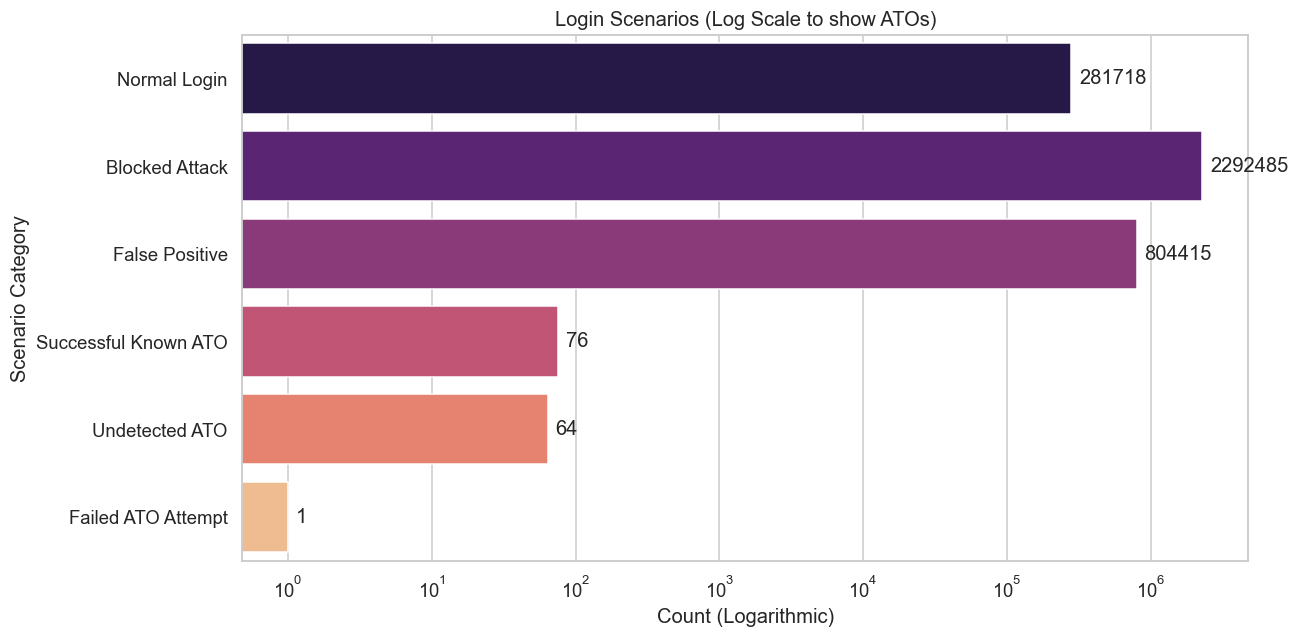

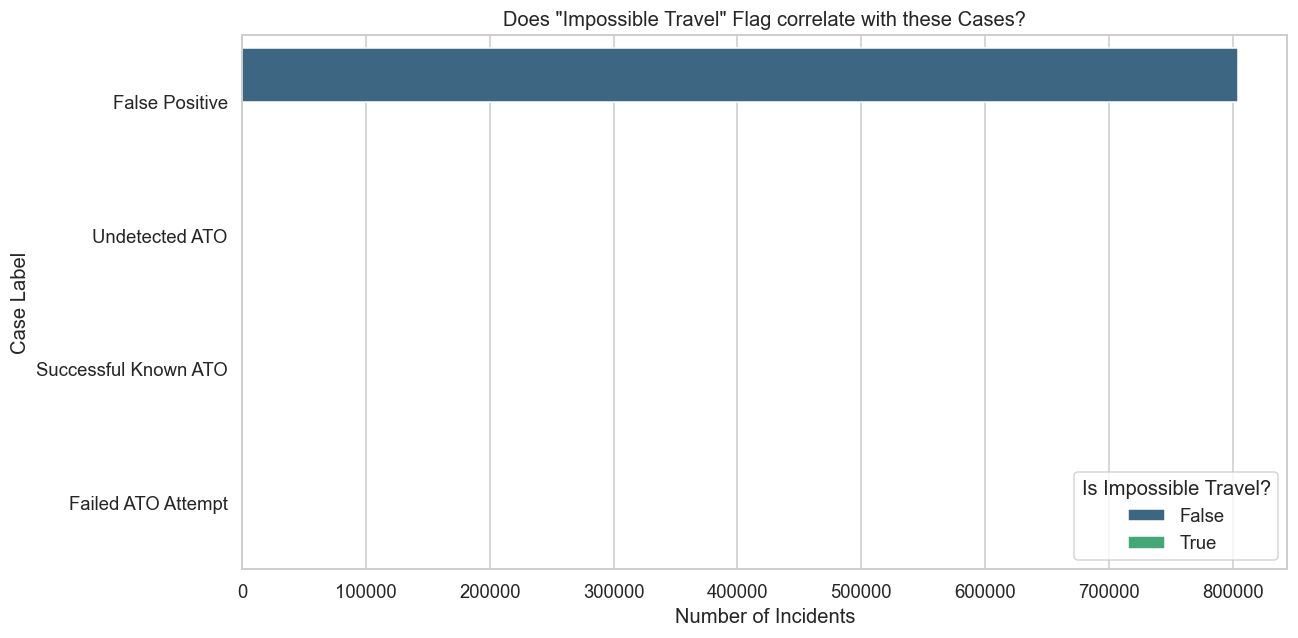

In [19]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, y='Case Label', palette='magma', 
                   order=['Normal Login', 'Blocked Attack', 'False Positive', 
                          'Successful Known ATO', 'Undetected ATO', 'Failed ATO Attempt'])

plt.xscale('log')
plt.title('Login Scenarios (Log Scale to show ATOs)')
plt.xlabel('Count (Logarithmic)')
plt.ylabel('Scenario Category')

# Add text labels for the exact counts on the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

# Plot 2: Impossible Travel vs. Scenarios
interesting_scenarios = ['False Positive', 'Successful Known ATO', 'Undetected ATO', 'Failed ATO Attempt']
df_filtered = df[df['Case Label'].isin(interesting_scenarios)]

plt.figure(figsize=(12, 6))
sns.countplot(data=df_filtered, y='Case Label', hue='is_impossible_travel', palette='viridis')
plt.title('Does "Impossible Travel" Flag correlate with these Cases?')
plt.xlabel('Number of Incidents')
plt.legend(title='Is Impossible Travel?', loc='lower right')
plt.tight_layout()
plt.show()

## <font color="orange">2. Where Are Attacks Coming From?</font>

Look at which countries have the highest ATO rate. We filter to countries with at least 20 logins to avoid noise from rare countries.

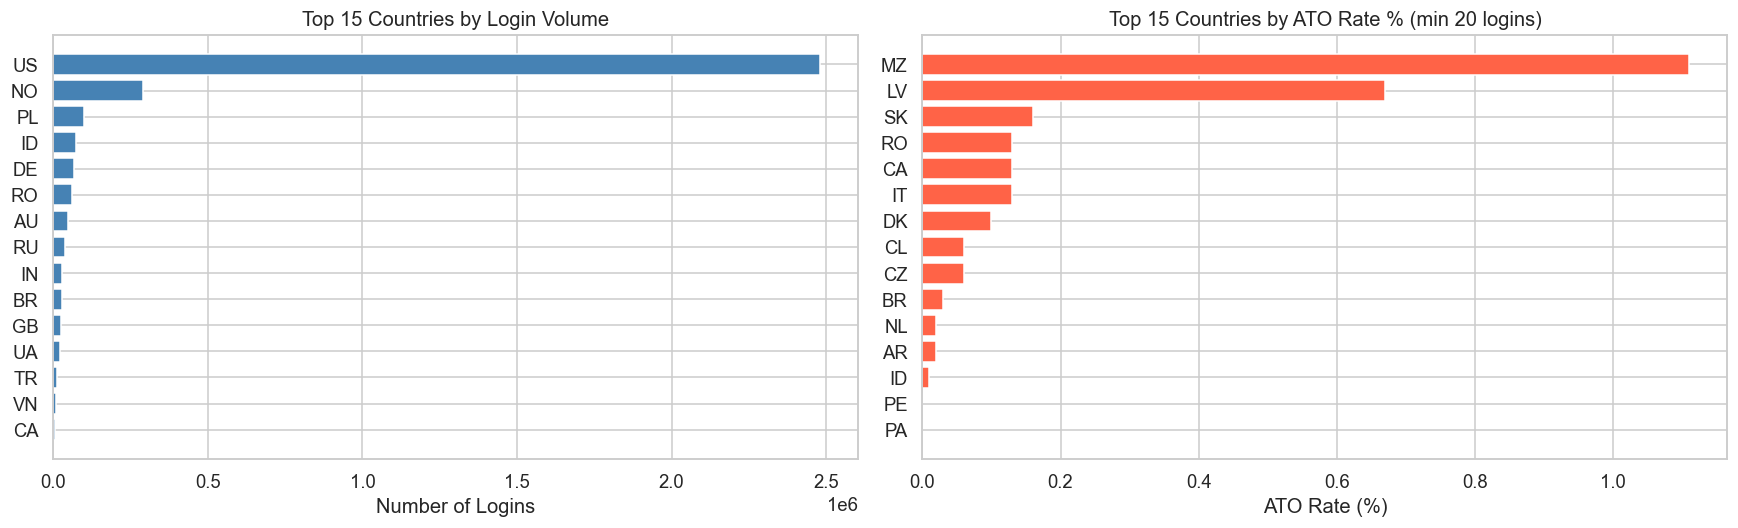

In [20]:
# Count total logins and ATOs per country
country_stats = df.groupby('Country').agg(
    total_logins=('Is Account Takeover', 'count'),
    ato_count=('Is Account Takeover', 'sum')
).reset_index()

# Calculate ATO rate, keep only countries with enough data
country_stats['ato_rate_%'] = (country_stats['ato_count'] / country_stats['total_logins'] * 100).round(2)
country_stats = country_stats[country_stats['total_logins'] >= 20].sort_values('ato_rate_%', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Login volume per country (top 15)
top_volume = country_stats.sort_values('total_logins', ascending=False).head(15)
axes[0].barh(top_volume['Country'], top_volume['total_logins'], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Countries by Login Volume')
axes[0].set_xlabel('Number of Logins')

# Right: ATO rate per country (top 15)
top_ato = country_stats.head(15)
axes[1].barh(top_ato['Country'], top_ato['ato_rate_%'], color='tomato')
axes[1].invert_yaxis()
axes[1].set_title('Top 15 Countries by ATO Rate % (min 20 logins)')
axes[1].set_xlabel('ATO Rate (%)')

plt.tight_layout()
plt.show()

In [28]:
df.loc[df['Is Account Takeover'] == 1, 'Country'].value_counts()

Country
RO    79
NO    10
CA     9
ID     9
BR     9
IT     7
DK     5
CL     3
LV     3
CZ     2
NL     1
MZ     1
RE     1
SK     1
AR     1
Name: count, dtype: int64

## <font color="orange">3. Device, Browser & OS Patterns</font>

Do attackers use different devices or browsers than normal users? Each chart shows the bar count alongside the ATO rate (red line).

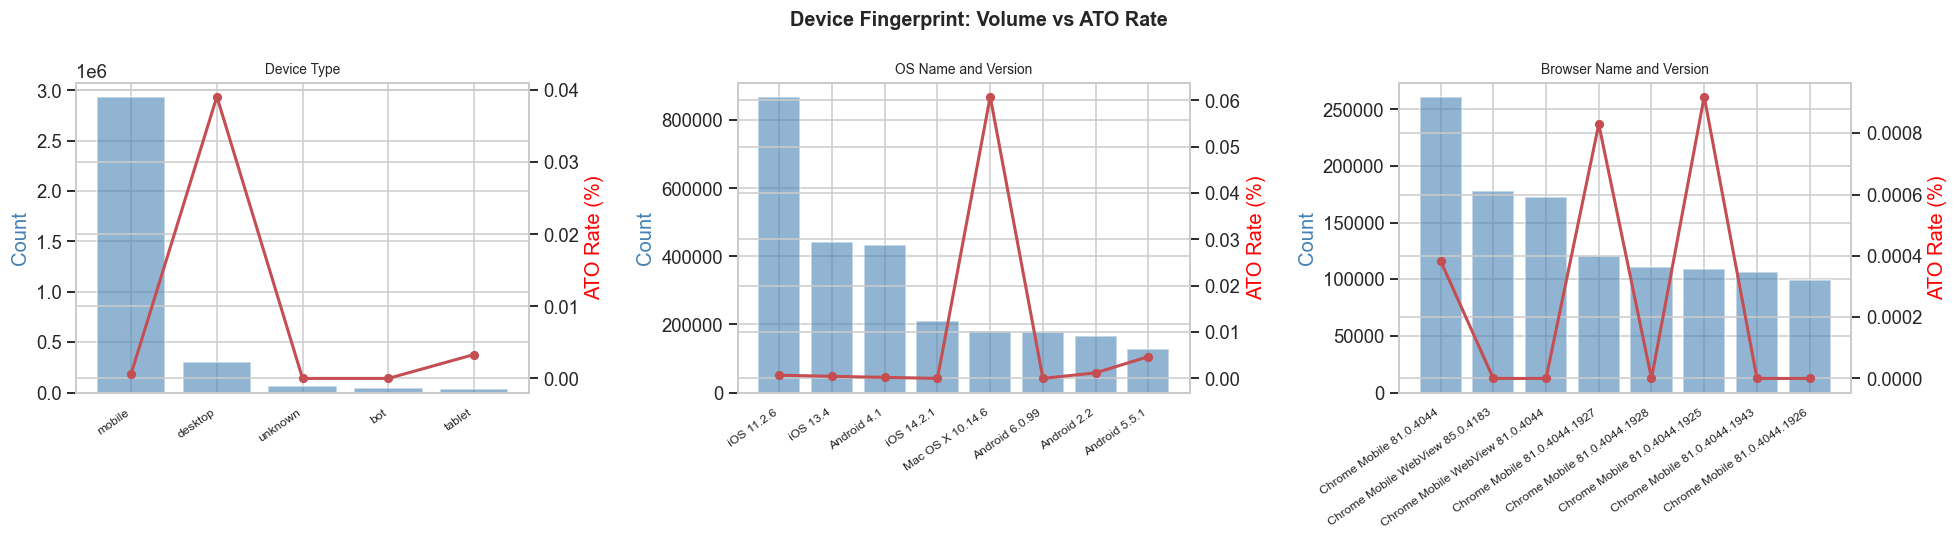

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['Device Type', 'OS Name and Version', 'Browser Name and Version']):
    # Take top 8 values to keep chart readable
    top_vals = df[col].value_counts().head(8).index
    sub = df[df[col].isin(top_vals)]

    counts = sub[col].value_counts().reindex(top_vals)
    ato_rate = sub.groupby(col)['Is Account Takeover'].mean().reindex(top_vals).mul(100)

    x = range(len(top_vals))
    ax2 = ax.twinx()  # second y-axis for ATO rate
    ax.bar(x, counts.values, color='steelblue', alpha=0.6, label='Count')
    ax2.plot(x, ato_rate.values, 'ro-', linewidth=2, markersize=5, label='ATO Rate')
    ax.set_xticks(x)
    ax.set_xticklabels(top_vals, rotation=35, ha='right', fontsize=8)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('Count', color='steelblue')
    ax2.set_ylabel('ATO Rate (%)', color='red')

plt.suptitle('Device Fingerprint: Volume vs ATO Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## <font color="orange">4. When Do Attacks Happen?</font>

Attackers may prefer certain hours or days when defenses are weaker. The heatmap shows ATO rate for every day-of-week × hour combination.

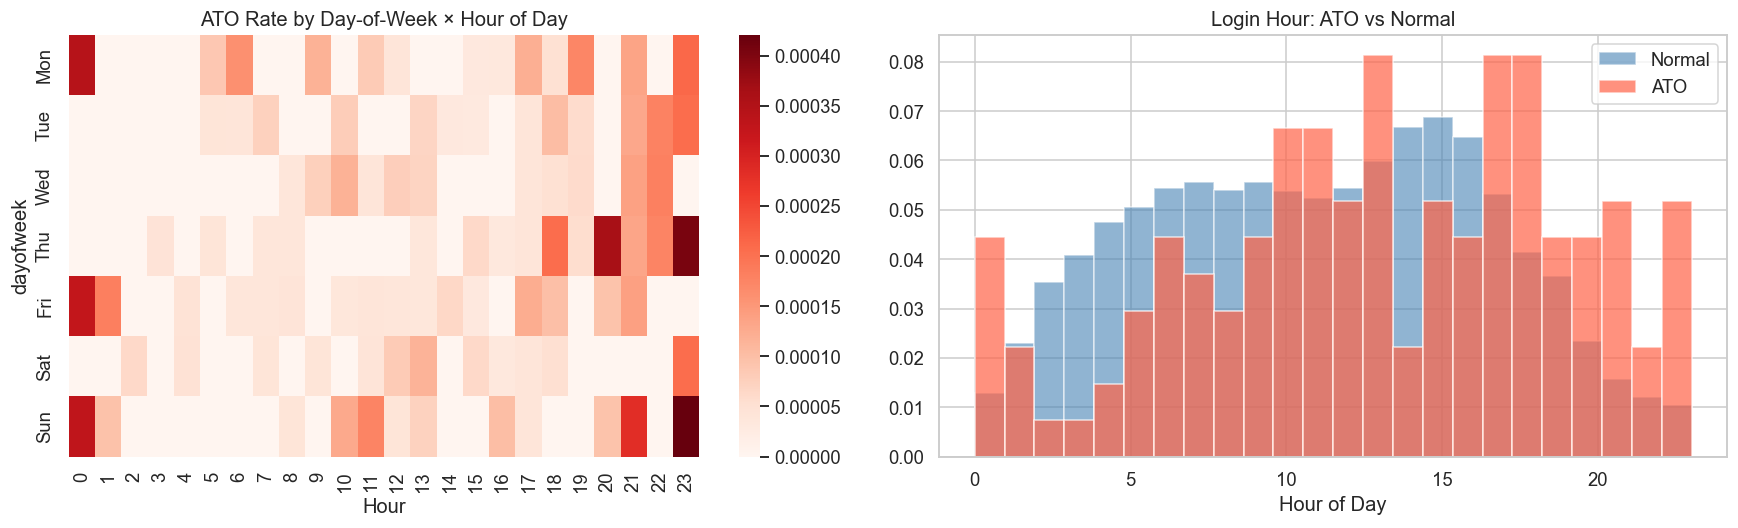

In [22]:
# Extract hour and day of week from the timestamp
df['hour'] = df['Login Timestamp'].dt.hour
df['dayofweek'] = df['Login Timestamp'].dt.dayofweek  # 0 = Monday

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: ATO rate heatmap by day × hour
pivot = df.groupby(['dayofweek', 'hour'])['Is Account Takeover'].mean().unstack(fill_value=0)
sns.heatmap(pivot, ax=axes[0], cmap='Reds',
            yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[0].set_title('ATO Rate by Day-of-Week × Hour of Day')
axes[0].set_xlabel('Hour')

# Right: Hour distribution — ATO vs Normal
df[df['Is Account Takeover'] == 0]['hour'].hist(
    ax=axes[1], bins=24, alpha=0.6, color='steelblue', density=True, label='Normal')
df[df['Is Account Takeover'] == 1]['hour'].hist(
    ax=axes[1], bins=24, alpha=0.7, color='tomato', density=True, label='ATO')
axes[1].set_title('Login Hour: ATO vs Normal')
axes[1].set_xlabel('Hour of Day')
axes[1].legend()

plt.tight_layout()
plt.show()

## <font color="orange">5. Round-Trip Time (RTT) Analysis</font>

RTT measures network latency. Attackers using VPNs or proxies may show unusual RTT values. We also flag RTT missingness as its own feature since it appears linked to attack traffic.

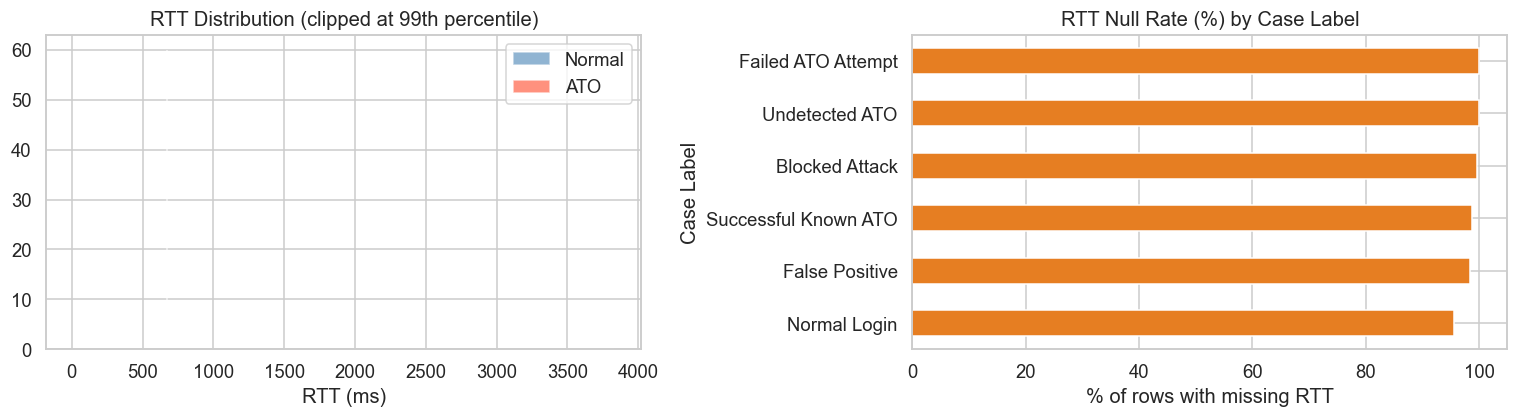

In [23]:
# Add a binary flag: is RTT missing?
df['rtt_missing'] = df['Round-Trip Time [ms]'].isna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: RTT distribution where available, ATO vs Normal
rtt_clip = df['Round-Trip Time [ms]'].clip(upper=df['Round-Trip Time [ms]'].quantile(0.99))
normal_rtt = rtt_clip[(df['Is Account Takeover'] == 0) & (~df['rtt_missing'])]
ato_rtt    = rtt_clip[(df['Is Account Takeover'] == 1) & (~df['rtt_missing'])]
axes[0].hist(normal_rtt, bins=60, alpha=0.6, color='steelblue', density=True, label='Normal')
axes[0].hist(ato_rtt,    bins=60, alpha=0.7, color='tomato',    density=True, label='ATO')
axes[0].set_title('RTT Distribution (clipped at 99th percentile)')
axes[0].set_xlabel('RTT (ms)')
axes[0].legend()

# Right: RTT null rate by Case Label
rtt_null_by_case = df.groupby('Case Label')['rtt_missing'].mean().mul(100).sort_values(ascending=False)
rtt_null_by_case.plot.barh(ax=axes[1], color='#e67e22')
axes[1].invert_yaxis()
axes[1].set_title('RTT Null Rate (%) by Case Label')
axes[1].set_xlabel('% of rows with missing RTT')

plt.tight_layout()
plt.show()

## <font color="orange">6. User-Level Behaviour</font>

We summarise each user's activity: how many logins, failed logins, countries, IPs, etc. Then compare ATO users vs normal users on these stats.

=== Average user behaviour: ATO vs Normal users ===
is_ato           False  True 
n_logins         3.853  5.964
fail_rate        0.456  0.061
n_countries      1.004  1.746
n_ips            1.425  3.862
n_devices        1.014  1.087
attack_ip_ever   0.847  0.725
imp_travel_ever  0.001  0.094


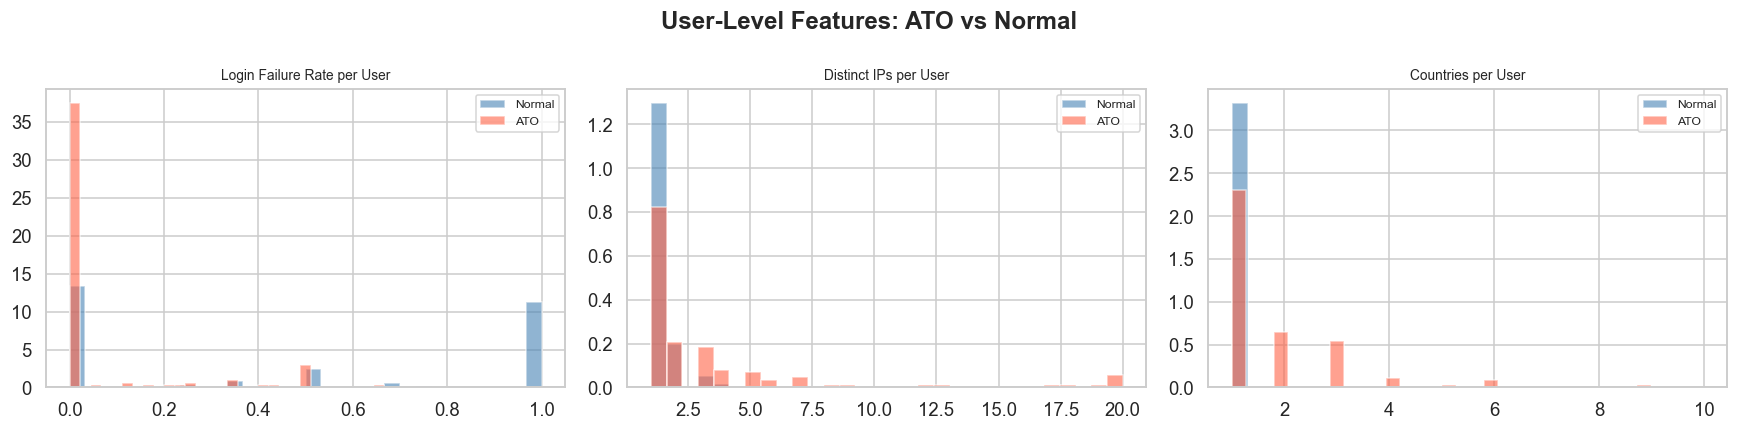

In [24]:
# Build one row per user summarising their behaviour
user_profile = df.groupby('User ID').agg(
    n_logins        = ('Login Timestamp', 'count'),
    fail_rate       = ('Login Successful', lambda x: (~x).mean()),
    n_countries     = ('Country', 'nunique'),
    n_ips           = ('IP Address', 'nunique'),
    n_devices       = ('Device Type', 'nunique'),
    attack_ip_ever  = ('Is Attack IP', 'max'),
    imp_travel_ever = ('is_impossible_travel', 'max'),
    is_ato          = ('Is Account Takeover', 'max'),
).reset_index()

print('=== Average user behaviour: ATO vs Normal users ===')
cols = ['n_logins','fail_rate','n_countries','n_ips','n_devices','attack_ip_ever','imp_travel_ever']
print(user_profile.groupby('is_ato')[cols].mean().round(3).T)

# Visualise the most informative features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title, clip_val in [
    (axes[0], 'fail_rate',    'Login Failure Rate per User', 1.0),
    (axes[1], 'n_ips',        'Distinct IPs per User',       20),
    (axes[2], 'n_countries',  'Countries per User',          10),
]:
    for label, color, mask in [
        ('Normal', 'steelblue', user_profile['is_ato'] == 0),
        ('ATO',    'tomato',    user_profile['is_ato'] == 1),
    ]:
        user_profile.loc[mask, col].clip(upper=clip_val).hist(
            ax=ax, bins=30, alpha=0.6, color=color, density=True, label=label)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('User-Level Features: ATO vs Normal', fontweight='bold')
plt.tight_layout()
plt.show()

## <font color="orange">7. Key Takeaways</font>

A printed summary of the most important numbers from this EDA.

In [25]:
ato_rate    = df['Is Account Takeover'].mean() * 100
attack_rate = df['Is Attack IP'].mean() * 100
it_rate     = df['is_impossible_travel'].mean() * 100
it_ato_rate = df[df['is_impossible_travel']]['Is Account Takeover'].mean() * 100
rtt_null    = df['rtt_missing'].mean() * 100

print('=' * 55)
print('           EDA KEY NUMBERS')
print('=' * 55)
print(f'  Total events            : {len(df):,}')
print(f'  Unique users            : {df["User ID"].nunique():,}')
print(f'  ATO rate (event-level)  : {ato_rate:.2f}%')
print(f'  Attack IP rate          : {attack_rate:.2f}%')
print(f'  Impossible travel rate  : {it_rate:.2f}%')
print(f'  ATO rate in imp. travel : {it_ato_rate:.2f}%')
print(f'  RTT null rate           : {rtt_null:.2f}%')
print('=' * 55)
print()
print('Top signals to explore for modelling:')
print('  1. is_impossible_travel  — your main new feature')
print('  2. Is Attack IP          — direct blacklist hit')
print('  3. rtt_missing           — null RTT = proxy/attack traffic?')
print('  4. fail_rate per user    — credential stuffing pattern')
print('  5. n_countries per user  — account used from many locations')
print('  6. n_ips per user        — proxy IP rotation signal')

           EDA KEY NUMBERS
  Total events            : 3,378,759
  Unique users            : 876,892
  ATO rate (event-level)  : 0.00%
  Attack IP rate          : 91.66%
  Impossible travel rate  : 20.59%
  ATO rate in imp. travel : 0.00%
  RTT null rate           : 99.04%

Top signals to explore for modelling:
  1. is_impossible_travel  — your main new feature
  2. Is Attack IP          — direct blacklist hit
  3. rtt_missing           — null RTT = proxy/attack traffic?
  4. fail_rate per user    — credential stuffing pattern
  5. n_countries per user  — account used from many locations
  6. n_ips per user        — proxy IP rotation signal
